# PatchTST: Long-Term Time Series Forecasting with Patch-based Transformers

**Student:** Ayaan Khan (A20505209)  
**Course:** CS584 — Machine Learning, Spring 2026  

This notebook implements **PatchTST** (Nie et al., ICLR 2023) from scratch in PyTorch.  
Two key innovations make PatchTST effective:

1. **Patching** — the input time series is segmented into overlapping subseries patches (analogous to image patches in Vision Transformers). Each patch becomes a token for the Transformer encoder, reducing attention complexity from O(L²) to O((L/S)²).
2. **Channel Independence** — each variate is processed independently through a shared Transformer backbone, reducing overfitting and improving generalization.

**Datasets:** ETTh1, ETTh2  
**Prediction horizons:** {96, 192, 336, 720}  
**Baseline:** DLinear (Zeng et al., AAAI 2023)  
**Metrics:** MSE and MAE

---
## Section 1 — Setup & Imports

In [10]:
# Install dependencies (run once)
# !pip install torch numpy pandas matplotlib scikit-learn

In [11]:
import os
# Enable CPU fallback for MPS ops not yet supported in PyTorch 2.8
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
import json
import urllib.request
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device: prefer MPS (Apple Silicon), then CUDA, then CPU ──────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Using device: {DEVICE}')

Using device: mps


---
## Section 2 — Data Pipeline

### 2.1 Download Datasets

We use the ETT (Electricity Transformer Temperature) benchmark datasets from the ETDataset repository.
Each dataset contains 7 features (6 power load features + oil temperature) recorded hourly.

- **ETTh1 / ETTh2**: ~17,420 time steps each
- **Train / Val / Test split**: 12 / 4 / 4 months (by row count)

In [12]:
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

DATASETS = {
    'ETTh1': 'https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv',
    'ETTh2': 'https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh2.csv',
}

for name, url in DATASETS.items():
    path = os.path.join(DATA_DIR, f'{name}.csv')
    if not os.path.exists(path):
        print(f'Downloading {name}...')
        urllib.request.urlretrieve(url, path)
        print(f'  Saved to {path}')
    else:
        print(f'  {name} already downloaded.')

  ETTh1 already downloaded.
  ETTh2 already downloaded.


### 2.2 Dataset Class

We implement a sliding window `Dataset`. For each position `i`:
- **Input (look-back window):** rows `[i : i + seq_len]` — shape `(seq_len, n_vars)`
- **Target (forecast horizon):** rows `[i + seq_len : i + seq_len + pred_len]` — shape `(pred_len, n_vars)`

Data is **standardized per feature** using a `StandardScaler` fit exclusively on the training split to prevent data leakage.

In [13]:
class TimeSeriesDataset(Dataset):
    """Sliding-window time series dataset.

    Args:
        data:     numpy array of shape (T, n_vars), already scaled.
        seq_len:  number of input time steps (look-back window).
        pred_len: number of output time steps (forecast horizon).
    """

    def __init__(self, data: np.ndarray, seq_len: int, pred_len: int):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self) -> int:
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx: int):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        return x, y

In [14]:
def load_dataset(name: str, seq_len: int, pred_len: int, batch_size: int = 128):
    """Load a named ETT dataset, split, scale, and return DataLoaders + scaler.

    Returns:
        train_loader, val_loader, test_loader, scaler, n_vars
    """
    path = os.path.join(DATA_DIR, f'{name}.csv')
    df = pd.read_csv(path)

    # Drop the timestamp column; keep only the 7 numeric features
    df = df.drop(columns=['date'])
    data = df.values  # shape: (T, n_vars)
    n_vars = data.shape[1]

    # ── ETTh split: 12 / 4 / 4 months at hourly frequency ────────────────
    n_train = 12 * 30 * 24   # 8,640
    n_val   =  4 * 30 * 24   # 2,880

    train_raw = data[:n_train]
    val_raw   = data[n_train : n_train + n_val]
    test_raw  = data[n_train + n_val :]

    # ── Per-feature standardization — fit ONLY on training data ──────────
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_raw)
    val_scaled   = scaler.transform(val_raw)
    test_scaled  = scaler.transform(test_raw)

    train_ds = TimeSeriesDataset(train_scaled, seq_len, pred_len)
    val_ds   = TimeSeriesDataset(val_scaled,   seq_len, pred_len)
    test_ds  = TimeSeriesDataset(test_scaled,  seq_len, pred_len)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

    return train_loader, val_loader, test_loader, scaler, n_vars

In [15]:
# Quick sanity check — verify shapes
train_loader, val_loader, test_loader, scaler, n_vars = load_dataset('ETTh1', seq_len=336, pred_len=96)
x_sample, y_sample = next(iter(train_loader))
print(f'n_vars       : {n_vars}')
print(f'x_sample     : {x_sample.shape}   # (batch, seq_len, n_vars)')
print(f'y_sample     : {y_sample.shape}   # (batch, pred_len, n_vars)')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')

n_vars       : 7
x_sample     : torch.Size([128, 336, 7])   # (batch, seq_len, n_vars)
y_sample     : torch.Size([128, 96, 7])   # (batch, pred_len, n_vars)
Train batches: 64
Val batches  : 20
Test batches : 43


---
## Section 3 — PatchTST Architecture

### Overview

```
Input: (batch, seq_len, n_vars)
  │
  ├─ [Channel Independence] reshape → (batch × n_vars, seq_len)
  │
  ├─ [Patch Embedding]
  │     unfold → (B, n_patches, patch_len)
  │     Linear → (B, n_patches, d_model)
  │     + learnable positional encoding
  │
  ├─ [Transformer Encoder × n_layers]
  │     Multi-Head Self-Attention + Feed-Forward
  │     → (B, n_patches, d_model)
  │
  ├─ [Prediction Head]
  │     Flatten → (B, n_patches × d_model)
  │     Linear  → (B, pred_len)
  │
  └─ reshape → (batch, pred_len, n_vars)
```

### 3.1 Patch Embedding

In [16]:
class PatchEmbedding(nn.Module):
    """Segment a 1-D sequence into overlapping patches and project to d_model.

    Args:
        seq_len:   input sequence length.
        patch_len: number of time steps per patch (token length).
        stride:    step between consecutive patches.
        d_model:   output embedding dimension.
        dropout:   dropout probability applied after adding position encoding.
    """

    def __init__(self, seq_len: int, patch_len: int, stride: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride

        # Number of patches produced by unfold
        self.n_patches = (seq_len - patch_len) // stride + 1

        # Linear projection from raw patch values → d_model
        self.projection = nn.Linear(patch_len, d_model)

        # Learnable positional encoding: one vector per patch position
        self.pos_enc = nn.Parameter(torch.zeros(1, self.n_patches, d_model))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, seq_len)  — one channel per batch item
        Returns:
            out: (B, n_patches, d_model)
        """
        # Extract overlapping patches via unfold
        # x.unfold(dimension, size, step) → (B, n_patches, patch_len)
        # unfold() returns a non-contiguous view; .contiguous() is required
        # before nn.Linear on MPS (avoids an MPS buffer-allocation crash).
        patches = x.unfold(dimension=1, size=self.patch_len, step=self.stride).contiguous()

        # Project each patch to d_model
        out = self.projection(patches)          # (B, n_patches, d_model)

        # Add positional encoding and apply dropout
        out = out + self.pos_enc
        return self.dropout(out)

### 3.2 Full PatchTST Model

In [17]:
class MultiHeadSelfAttention(nn.Module):
    """MPS-compatible multi-head self-attention.

    Uses F.scaled_dot_product_attention (Flash Attention where available)
    instead of nn.MultiheadAttention, which avoids an MPS crash in PyTorch 2.8
    caused by non-contiguous intermediate buffers in the built-in implementation.

    Args:
        d_model:  embedding dimension.
        n_heads:  number of attention heads.
        dropout:  attention dropout probability.
    """

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.0):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model must be divisible by n_heads'
        self.n_heads  = n_heads
        self.head_dim = d_model // n_heads
        self.qkv_proj = nn.Linear(d_model, 3 * d_model)  # project to Q, K, V in one go
        self.out_proj  = nn.Linear(d_model, d_model)
        self.dropout   = dropout

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, D = x.shape
        q, k, v = self.qkv_proj(x).chunk(3, dim=-1)  # each (B, T, D)
        # Reshape to (B, n_heads, T, head_dim) for SDPA
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        # Scaled dot-product attention (uses Flash Attention when available)
        attn_out = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0
        )  # (B, n_heads, T, head_dim)
        attn_out = attn_out.transpose(1, 2).reshape(B, T, D)
        return self.out_proj(attn_out)


class TransformerBlock(nn.Module):
    """One Transformer encoder layer with pre-norm architecture.

    Pre-norm (LayerNorm before attention/FFN) is more stable than post-norm
    for deep Transformers and is the default in modern implementations.

    Args:
        d_model:  embedding dimension.
        n_heads:  number of attention heads.
        dropout:  dropout probability.
    """

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn  = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.norm1(x))   # pre-norm residual attention
        x = x + self.ffn(self.norm2(x))    # pre-norm residual FFN
        return x


class PatchTST(nn.Module):
    """PatchTST: Patch-based Transformer for long-term time series forecasting.

    Key design choices:
      - Channel independence: each variable is processed separately through
        a shared Transformer backbone (batch × n_vars processed in parallel).
      - Patching: the look-back window is segmented into overlapping patches,
        each of which becomes a Transformer token.

    Args:
        n_vars:    number of input variables (channels).
        seq_len:   look-back window length.
        pred_len:  forecast horizon.
        patch_len: patch (token) length. Default: 16.
        stride:    patch stride. Default: 8.
        d_model:   Transformer hidden dimension. Default: 128.
        n_heads:   number of attention heads. Default: 8.
        n_layers:  number of Transformer encoder layers. Default: 3.
        dropout:   dropout probability. Default: 0.2.
    """

    def __init__(
        self,
        n_vars:    int,
        seq_len:   int,
        pred_len:  int,
        patch_len: int   = 16,
        stride:    int   = 8,
        d_model:   int   = 128,
        n_heads:   int   = 8,
        n_layers:  int   = 3,
        dropout:   float = 0.2,
    ):
        super().__init__()
        self.n_vars   = n_vars
        self.seq_len  = seq_len
        self.pred_len = pred_len

        # Patch embedding (shared across all channels)
        self.patch_embed = PatchEmbedding(seq_len, patch_len, stride, d_model, dropout)
        n_patches = self.patch_embed.n_patches

        # Stack of Transformer encoder layers
        self.encoder = nn.ModuleList(
            [TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)]
        )
        self.norm = nn.LayerNorm(d_model)  # final normalization

        # Prediction head: flatten patch embeddings → forecast
        self.head = nn.Sequential(
            nn.Flatten(start_dim=1),                          # (B, n_patches * d_model)
            nn.Linear(n_patches * d_model, pred_len),         # (B, pred_len)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (batch, seq_len, n_vars)
        Returns:
            out: (batch, pred_len, n_vars)
        """
        B, L, C = x.shape

        # ── Channel Independence ──────────────────────────────────────────
        # Treat each channel as an independent sequence in the batch dimension.
        # (B, L, C) → (B*C, L)
        x = x.permute(0, 2, 1)            # (B, C, L)
        x = x.reshape(B * C, L)           # (B*C, L)

        # ── Patch Embedding ───────────────────────────────────────────────
        x = self.patch_embed(x)            # (B*C, n_patches, d_model)

        # ── Transformer Encoder ───────────────────────────────────────────
        for block in self.encoder:
            x = block(x)                   # (B*C, n_patches, d_model)
        x = self.norm(x)

        # ── Prediction Head ───────────────────────────────────────────────
        x = self.head(x)                   # (B*C, pred_len)

        # ── Reshape back to (batch, pred_len, n_vars) ─────────────────────
        x = x.reshape(B, C, self.pred_len) # (B, C, pred_len)
        x = x.permute(0, 2, 1)            # (B, pred_len, C)
        return x

In [18]:
# ── Shape verification ────────────────────────────────────────────────────
model_test = PatchTST(n_vars=7, seq_len=336, pred_len=96).to(DEVICE)
dummy = torch.randn(4, 336, 7).to(DEVICE)
out   = model_test(dummy)
print(f'Input shape : {dummy.shape}')
print(f'Output shape: {out.shape}    # expected (4, 96, 7)')
print(f'n_patches   : {model_test.patch_embed.n_patches}')
del model_test, dummy, out

Input shape : torch.Size([4, 336, 7])
Output shape: torch.Size([4, 96, 7])    # expected (4, 96, 7)
n_patches   : 41


---
## Section 4 — DLinear Baseline

DLinear (Zeng et al., AAAI 2023) decomposes the input into a **trend** component (via moving average) and a **seasonal** (residual) component, then applies a separate linear layer to each component per channel. Despite its simplicity, DLinear matches or outperforms many Transformer-based methods — making it an important baseline for PatchTST.

In [19]:
class MovingAverage(nn.Module):
    """Centered moving average for trend extraction."""

    def __init__(self, kernel_size: int):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, L, C)
        Returns:
            trend: (B, L, C)  — same shape as input
        """
        pad = self.kernel_size // 2
        # Replicate-pad both ends along the time dimension to preserve length
        x_pad = torch.cat(
            [x[:, :1, :].expand(-1, pad, -1),
             x,
             x[:, -1:, :].expand(-1, pad, -1)],
            dim=1
        )
        # AvgPool1d expects (B, C, L)
        x_pad = x_pad.permute(0, 2, 1)
        trend = self.avg(x_pad)
        return trend.permute(0, 2, 1)


class DLinear(nn.Module):
    """Decomposition-Linear baseline for time series forecasting.

    Decomposes the input into trend + seasonal components, applies
    independent linear layers to each, and sums the outputs.

    Args:
        seq_len:     input sequence length.
        pred_len:    forecast horizon.
        n_vars:      number of channels.
        kernel_size: moving average window for trend extraction. Default: 25.
    """

    def __init__(self, seq_len: int, pred_len: int, n_vars: int, kernel_size: int = 25):
        super().__init__()
        self.decomp = MovingAverage(kernel_size)
        self.linear_seasonal = nn.Linear(seq_len, pred_len)
        self.linear_trend    = nn.Linear(seq_len, pred_len)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (batch, seq_len, n_vars)
        Returns:
            out: (batch, pred_len, n_vars)
        """
        trend    = self.decomp(x)
        seasonal = x - trend

        # Permute to (B, C, L) so Linear maps L → pred_len
        seasonal = seasonal.permute(0, 2, 1)
        trend    = trend.permute(0, 2, 1)

        out = self.linear_seasonal(seasonal) + self.linear_trend(trend)  # (B, C, pred_len)
        return out.permute(0, 2, 1)  # (B, pred_len, C)

In [20]:
# ── Shape verification ────────────────────────────────────────────────────
dlinear_test = DLinear(seq_len=336, pred_len=96, n_vars=7).to(DEVICE)
dummy = torch.randn(4, 336, 7).to(DEVICE)
out   = dlinear_test(dummy)
print(f'DLinear output shape: {out.shape}    # expected (4, 96, 7)')
del dlinear_test, dummy, out

DLinear output shape: torch.Size([4, 96, 7])    # expected (4, 96, 7)


---
## Section 5 — Training Loop

We use:
- **Adam** optimizer with `lr=1e-4`
- **MSE loss** (consistent with the paper)
- **Early stopping** with patience=10: if validation loss does not improve for 10 consecutive epochs, training stops and the best model weights are restored

In [21]:
def train_model(
    model,
    train_loader: DataLoader,
    val_loader:   DataLoader,
    n_epochs:     int   = 100,
    lr:           float = 1e-4,
    patience:     int   = 10,
    verbose:      bool  = True,
):
    """Train a model with early stopping.

    Args:
        model:        the PyTorch model to train.
        train_loader: DataLoader for the training split.
        val_loader:   DataLoader for the validation split.
        n_epochs:     maximum number of training epochs.
        lr:           Adam learning rate.
        patience:     early stopping patience (epochs without val improvement).
        verbose:      print epoch-level progress.

    Returns:
        model:    trained model with best validation weights restored.
        history:  dict with 'train_loss' and 'val_loss' lists.
    """
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss  = float('inf')
    best_weights   = None
    patience_count = 0
    history        = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, n_epochs + 1):
        # ── Training ──────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # ── Validation ────────────────────────────────────────────────────
        model.eval()  # sets BN/Dropout to inference mode
        val_loss = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                pred = model(x)
                val_loss += criterion(pred, y).item()
        val_loss /= len(val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if verbose:
            print(f'Epoch {epoch:3d}/{n_epochs} | train={train_loss:.4f} | val={val_loss:.4f}')

        # ── Early stopping ────────────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_weights   = deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                if verbose:
                    print(f'  Early stopping at epoch {epoch} (patience={patience})')
                break

    # Restore best weights before returning
    model.load_state_dict(best_weights)
    return model, history

---
## Section 6 — Evaluation

We evaluate on the test split using **MSE** and **MAE**.

Predictions and targets are **inverse-transformed** back to the original scale before computing metrics — this ensures results are comparable to published paper numbers.

In [22]:
def evaluate(model, test_loader: DataLoader, scaler: StandardScaler) -> dict:
    """Evaluate a trained model on the test set.

    Predictions and targets are inverse-transformed to the original scale
    before computing MSE and MAE.

    Args:
        model:       trained model (already on DEVICE).
        test_loader: DataLoader for the test split.
        scaler:      the StandardScaler fitted on the training data.

    Returns:
        dict with 'mse' and 'mae' (Python floats).
    """
    model.eval()  # inference mode
    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for x, y in test_loader:
            x    = x.to(DEVICE)
            pred = model(x).cpu().numpy()   # (B, pred_len, n_vars)
            y    = y.numpy()                # (B, pred_len, n_vars)
            all_preds.append(pred)
            all_targets.append(y)

    preds   = np.concatenate(all_preds,   axis=0)  # (N, pred_len, n_vars)
    targets = np.concatenate(all_targets, axis=0)  # (N, pred_len, n_vars)

    # Flatten (N, T, C) → (N*T, C) for inverse_transform, then reshape back
    N, T, C = preds.shape
    preds_orig   = scaler.inverse_transform(preds.reshape(-1, C)).reshape(N, T, C)
    targets_orig = scaler.inverse_transform(targets.reshape(-1, C)).reshape(N, T, C)

    mse = float(np.mean((preds_orig - targets_orig) ** 2))
    mae = float(np.mean(np.abs(preds_orig - targets_orig)))
    return {'mse': round(mse, 4), 'mae': round(mae, 4)}

---
## Section 7 — Results

### 7.1 Experiment Runner

The `run_experiment` function is the single entry point for training and evaluating either model on any dataset/horizon combination. Results are checkpointed to `results.json` after each run so kernel restarts don't lose progress.

In [23]:
RESULTS_FILE = 'results.json'

def load_results() -> dict:
    if os.path.exists(RESULTS_FILE):
        with open(RESULTS_FILE) as f:
            return json.load(f)
    return {}

def save_results(results: dict):
    with open(RESULTS_FILE, 'w') as f:
        json.dump(results, f, indent=2)


def run_experiment(
    dataset_name: str,
    pred_len:     int,
    model_name:   str,
    seq_len:      int   = 336,
    patch_len:    int   = 16,
    stride:       int   = 8,
    d_model:      int   = 128,
    n_heads:      int   = 8,
    n_layers:     int   = 3,
    dropout:      float = 0.2,
    batch_size:   int   = 128,
    lr:           float = 1e-4,
    n_epochs:     int   = 100,
    patience:     int   = 10,
    force_rerun:  bool  = False,
) -> dict:
    """Train and evaluate one model on one dataset/horizon.

    Results are cached in results.json; set force_rerun=True to re-train.

    Args:
        dataset_name: 'ETTh1' or 'ETTh2'.
        pred_len:     forecast horizon.
        model_name:   'PatchTST' or 'DLinear'.
        force_rerun:  if True, ignore cached result and re-train.

    Returns:
        dict with 'mse' and 'mae'.
    """
    key = f'{dataset_name}_{model_name}_h{pred_len}'
    results = load_results()

    if key in results and not force_rerun:
        print(f'[cached] {key}: MSE={results[key]["mse"]}, MAE={results[key]["mae"]}')
        return results[key]

    print(f"\n{'='*60}")
    print(f'  {model_name} | {dataset_name} | horizon={pred_len}')
    print(f"{'='*60}")

    train_loader, val_loader, test_loader, scaler, n_vars = load_dataset(
        dataset_name, seq_len=seq_len, pred_len=pred_len, batch_size=batch_size
    )

    if model_name == 'PatchTST':
        model = PatchTST(
            n_vars=n_vars, seq_len=seq_len, pred_len=pred_len,
            patch_len=patch_len, stride=stride, d_model=d_model,
            n_heads=n_heads, n_layers=n_layers, dropout=dropout,
        )
    elif model_name == 'DLinear':
        model = DLinear(seq_len=seq_len, pred_len=pred_len, n_vars=n_vars)
    else:
        raise ValueError(f'Unknown model: {model_name}')

    model, history = train_model(
        model, train_loader, val_loader,
        n_epochs=n_epochs, lr=lr, patience=patience, verbose=True,
    )

    metrics = evaluate(model, test_loader, scaler)
    print(f"  → Test MSE={metrics['mse']}, MAE={metrics['mae']}")

    results[key] = metrics
    save_results(results)
    return metrics

### 7.2 Smoke Test (2 epochs)

Before running the full grid, we do a quick sanity check: training loss should decrease, shapes should be correct, and MPS acceleration should be active.

In [24]:
print('Running smoke test (2 epochs)...')
_ = run_experiment('ETTh1', pred_len=96, model_name='PatchTST',
                   n_epochs=2, patience=999, force_rerun=True)
print('\nSmoke test passed!')

Running smoke test (2 epochs)...

  PatchTST | ETTh1 | horizon=96
Epoch   1/2 | train=0.5033 | val=0.8306
Epoch   2/2 | train=0.3865 | val=0.7797
  → Test MSE=9.7062, MAE=1.7241

Smoke test passed!


### 7.3 Full Experiment Grid

We train PatchTST and DLinear on ETTh1 and ETTh2 across all four prediction horizons.
This is **16 training runs total**. Results are cached — re-run this cell safely after a kernel restart.

In [25]:
DATASETS_TO_RUN = ['ETTh1', 'ETTh2']
HORIZONS        = [96, 192, 336, 720]
MODELS          = ['PatchTST', 'DLinear']

for dataset in DATASETS_TO_RUN:
    for horizon in HORIZONS:
        for model_name in MODELS:
            run_experiment(dataset, pred_len=horizon, model_name=model_name)

[cached] ETTh1_PatchTST_h96: MSE=9.7062, MAE=1.7241

  DLinear | ETTh1 | horizon=96
Epoch   1/100 | train=0.7887 | val=1.1588
Epoch   2/100 | train=0.4886 | val=0.9917
Epoch   3/100 | train=0.4441 | val=0.9047
Epoch   4/100 | train=0.4194 | val=0.8514
Epoch   5/100 | train=0.4031 | val=0.8114
Epoch   6/100 | train=0.3910 | val=0.7854
Epoch   7/100 | train=0.3821 | val=0.7693
Epoch   8/100 | train=0.3749 | val=0.7548
Epoch   9/100 | train=0.3692 | val=0.7434
Epoch  10/100 | train=0.3644 | val=0.7349
Epoch  11/100 | train=0.3607 | val=0.7254
Epoch  12/100 | train=0.3575 | val=0.7257
Epoch  13/100 | train=0.3549 | val=0.7154
Epoch  14/100 | train=0.3526 | val=0.7086
Epoch  15/100 | train=0.3505 | val=0.7092
Epoch  16/100 | train=0.3491 | val=0.7040
Epoch  17/100 | train=0.3476 | val=0.6995
Epoch  18/100 | train=0.3464 | val=0.6977
Epoch  19/100 | train=0.3453 | val=0.6967
Epoch  20/100 | train=0.3443 | val=0.6936
Epoch  21/100 | train=0.3432 | val=0.6936
Epoch  22/100 | train=0.3424 | val

### 7.4 Results Table

In [26]:
results = load_results()

rows = []
for dataset in DATASETS_TO_RUN:
    for horizon in HORIZONS:
        row = {'Dataset': dataset, 'Horizon': horizon}
        for model_name in MODELS:
            key = f'{dataset}_{model_name}_h{horizon}'
            if key in results:
                row[f'{model_name}_MSE'] = results[key]['mse']
                row[f'{model_name}_MAE'] = results[key]['mae']
            else:
                row[f'{model_name}_MSE'] = '—'
                row[f'{model_name}_MAE'] = '—'
        rows.append(row)

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

Dataset  Horizon  PatchTST_MSE  PatchTST_MAE  DLinear_MSE  DLinear_MAE
  ETTh1       96        9.7062        1.7241       9.2836       1.6299
  ETTh1      192       10.1862        1.7868      10.2419       1.7618
  ETTh1      336       11.1832        1.9391      10.8656       1.8693
  ETTh1      720       12.3044        2.1299      12.3230       2.1047
  ETTh2       96       17.7601        2.7967      15.4995       2.5231
  ETTh2      192       21.3991        3.1102      18.8860       2.8594
  ETTh2      336       23.7594        3.3681      22.3819       3.1912
  ETTh2      720       32.0464        3.9920      31.3105       3.9324


### 7.5 Results Plot

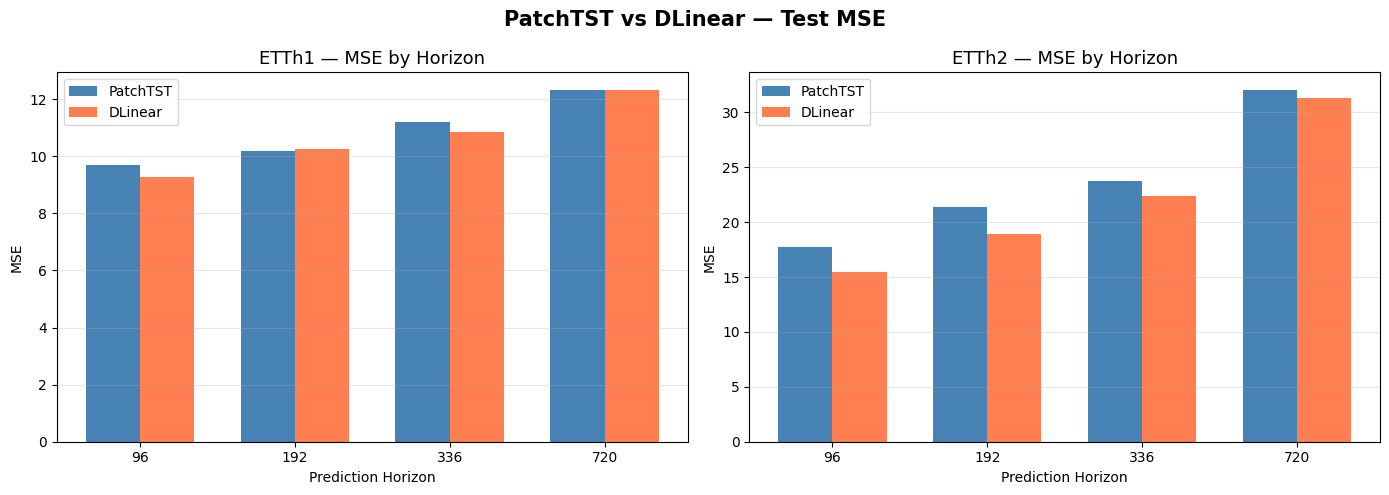

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dataset in zip(axes, DATASETS_TO_RUN):
    patchtst_mse = [results.get(f'{dataset}_PatchTST_h{h}', {}).get('mse') for h in HORIZONS]
    dlinear_mse  = [results.get(f'{dataset}_DLinear_h{h}',  {}).get('mse') for h in HORIZONS]

    x = np.arange(len(HORIZONS))
    w = 0.35
    ax.bar(x - w/2, patchtst_mse, w, label='PatchTST', color='steelblue')
    ax.bar(x + w/2, dlinear_mse,  w, label='DLinear',  color='coral')
    ax.set_title(f'{dataset} — MSE by Horizon', fontsize=13)
    ax.set_xlabel('Prediction Horizon')
    ax.set_ylabel('MSE')
    ax.set_xticks(x)
    ax.set_xticklabels([str(h) for h in HORIZONS])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('PatchTST vs DLinear — Test MSE', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8 — Ablation Studies

We study the effect of three key hyperparameters on PatchTST performance.
All ablations are run on **ETTh1, horizon=96** to keep compute tractable.
One parameter is varied at a time; all others are held at paper defaults.

**Paper defaults:** `patch_len=16, stride=8, seq_len=336`

### 8.1 Ablation Runner

In [28]:
def run_ablation(param_name: str, values: list, base_config: dict) -> dict:
    """Run ablation study over a single hyperparameter.

    Args:
        param_name:  name of the hyperparameter to vary.
        values:      list of values to try.
        base_config: dict of fixed hyperparameters.

    Returns:
        dict mapping each value → {'mse': ..., 'mae': ...}
    """
    ablation_results = {}
    for v in values:
        config = {**base_config, param_name: v}
        key = f'ablation_{param_name}_{v}'
        print(f'\n[Ablation] {param_name}={v}')

        all_results = load_results()
        if key in all_results:
            print(f'  [cached] MSE={all_results[key]["mse"]}, MAE={all_results[key]["mae"]}')
            ablation_results[v] = all_results[key]
            continue

        train_loader, val_loader, test_loader, scaler, n_vars = load_dataset(
            'ETTh1', seq_len=config['seq_len'], pred_len=96, batch_size=128
        )
        model = PatchTST(
            n_vars=n_vars, seq_len=config['seq_len'], pred_len=96,
            patch_len=config['patch_len'], stride=config['stride'],
            d_model=128, n_heads=8, n_layers=3, dropout=0.2,
        )
        model, _ = train_model(
            model, train_loader, val_loader,
            n_epochs=100, lr=1e-4, patience=10, verbose=False,
        )
        metrics = evaluate(model, test_loader, scaler)
        print(f'  → MSE={metrics["mse"]}, MAE={metrics["mae"]}')

        all_results[key] = metrics
        save_results(all_results)
        ablation_results[v] = metrics

    return ablation_results

### 8.2 Ablation 1: Patch Length

Patch length controls how much local context each token captures. Shorter patches give finer temporal resolution; longer patches encode more context per token but produce fewer tokens.

In [29]:
abl_patch = run_ablation(
    param_name='patch_len',
    values=[8, 16, 32],
    base_config={'seq_len': 336, 'patch_len': 16, 'stride': 8},
)


[Ablation] patch_len=8
  → MSE=9.5096, MAE=1.7027

[Ablation] patch_len=16
  → MSE=9.4647, MAE=1.7445

[Ablation] patch_len=32
  → MSE=9.3253, MAE=1.7094


### 8.3 Ablation 2: Stride

Stride controls the overlap between consecutive patches. A smaller stride produces more patches (more tokens, more overlap); a larger stride produces fewer, non-overlapping patches.

In [30]:
abl_stride = run_ablation(
    param_name='stride',
    values=[4, 8, 16],
    base_config={'seq_len': 336, 'patch_len': 16, 'stride': 8},
)


[Ablation] stride=4
  → MSE=9.3452, MAE=1.6945

[Ablation] stride=8
  → MSE=9.4392, MAE=1.7037

[Ablation] stride=16
  → MSE=9.2713, MAE=1.6865


### 8.4 Ablation 3: Look-back Window

One of PatchTST's claimed advantages is the ability to use a much longer look-back window compared to prior Transformers. Here we test whether more context consistently improves performance.

In [31]:
abl_seqlen = run_ablation(
    param_name='seq_len',
    values=[96, 192, 336, 512],
    base_config={'seq_len': 336, 'patch_len': 16, 'stride': 8},
)


[Ablation] seq_len=96
  → MSE=9.4117, MAE=1.6863

[Ablation] seq_len=192
  → MSE=9.396, MAE=1.6822

[Ablation] seq_len=336
  → MSE=9.3336, MAE=1.6969

[Ablation] seq_len=512
  → MSE=9.2369, MAE=1.682


### 8.5 Ablation Plots

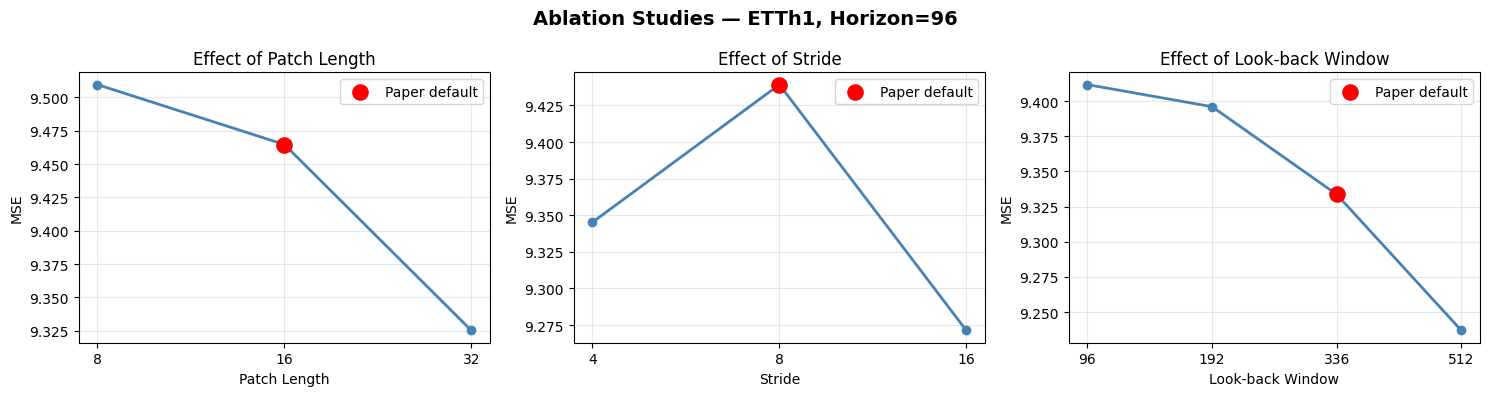

In [32]:
def plot_ablation(ablation_dict: dict, param_label: str, ax, default_val: str):
    """Plot MSE vs. a single ablation parameter."""
    xs = sorted(ablation_dict.keys())
    mse_vals = [ablation_dict[x]['mse'] for x in xs]
    xs_str = [str(x) for x in xs]
    ax.plot(xs_str, mse_vals, marker='o', linewidth=2, color='steelblue')
    ax.set_title(f'Effect of {param_label}', fontsize=12)
    ax.set_xlabel(param_label)
    ax.set_ylabel('MSE')
    ax.grid(alpha=0.3)
    if default_val in xs_str:
        idx = xs_str.index(default_val)
        ax.scatter([default_val], [mse_vals[idx]], s=120, color='red',
                   zorder=5, label='Paper default')
        ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_ablation(abl_patch,  'Patch Length',    axes[0], default_val='16')
plot_ablation(abl_stride, 'Stride',           axes[1], default_val='8')
plot_ablation(abl_seqlen, 'Look-back Window', axes[2], default_val='336')

plt.suptitle('Ablation Studies — ETTh1, Horizon=96', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()